# HW05 - MNIST with JAX

In [8]:
import math
import pathlib
import time
from dataclasses import dataclass

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests



SEED = 7
NUM_CLASSES = 10
SUBSET_SIZE = 12000
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
K_FOLDS = 5
BATCH_SIZE = 256
EPOCHS = 35
LR = 0.15
TREE_MAX_DEPTH = 7
TREE_MIN_SAMPLES_SPLIT = 30
TREE_MIN_SAMPLES_LEAF = 15
TREE_MAX_FEATURES = 12
TREE_THRESHOLD_COUNT = 10
PCA_COMPONENTS = 40

MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
CACHE_DIR = pathlib.Path.home() / ".cache" / "hw05_mnist"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
MNIST_PATH = CACHE_DIR / "mnist.npz"


def download_mnist(path: pathlib.Path = MNIST_PATH) -> pathlib.Path:
    if not path.exists():
        response = requests.get(MNIST_URL, timeout=120)
        response.raise_for_status()
        path.write_bytes(response.content)
    return path


def load_mnist() -> tuple[np.ndarray, np.ndarray]:
    path = download_mnist()
    with np.load(path) as data:
        x_train = data["x_train"]
        y_train = data["y_train"]
        x_test = data["x_test"]
        y_test = data["y_test"]
    x_all = np.concatenate([x_train, x_test], axis=0).astype(np.float32) / 255.0
    y_all = np.concatenate([y_train, y_test], axis=0).astype(np.int32)
    return x_all.reshape(len(x_all), -1), y_all


X_all, y_all = load_mnist()
print(f"MNIST loaded: {X_all.shape[0]} samples, {X_all.shape[1]} features")

MNIST loaded: 70000 samples, 784 features


In [2]:
rng = np.random.default_rng(SEED)


def one_hot(y: np.ndarray, num_classes: int = NUM_CLASSES) -> np.ndarray:
    return np.eye(num_classes, dtype=np.float32)[y]


def stratified_split(y: np.ndarray, train_frac: float = TRAIN_FRAC, val_frac: float = VAL_FRAC, test_frac: float = TEST_FRAC, seed: int = SEED):
    if not np.isclose(train_frac + val_frac + test_frac, 1.0):
        raise ValueError("Fractions must sum to 1.0")
    rng_local = np.random.default_rng(seed)
    classes = np.unique(y)
    train_parts, val_parts, test_parts = [], [], []
    for cls in classes:
        cls_idx = np.flatnonzero(y == cls)
        rng_local.shuffle(cls_idx)
        n = len(cls_idx)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        n_train = min(n_train, n)
        n_val = min(n_val, n - n_train)
        train_parts.append(cls_idx[:n_train])
        val_parts.append(cls_idx[n_train:n_train + n_val])
        test_parts.append(cls_idx[n_train + n_val:])

    def _pack(parts: list[np.ndarray]) -> np.ndarray:
        idx = np.concatenate(parts)
        rng_local.shuffle(idx)
        return idx

    return _pack(train_parts), _pack(val_parts), _pack(test_parts)


def standardize_fit(x: np.ndarray):
    mean = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True) + 1e-8
    return mean, std


def standardize_apply(x: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return (x - mean) / std


def softmax(logits):
    shifted = logits - jnp.max(logits, axis=1, keepdims=True)
    exp_logits = jnp.exp(shifted)
    return exp_logits / jnp.sum(exp_logits, axis=1, keepdims=True)


def cross_entropy_from_logits(logits, targets_one_hot):
    probs = softmax(logits)
    return -jnp.mean(jnp.sum(targets_one_hot * jnp.log(probs + 1e-9), axis=1))


def confusion_matrix_numpy(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int = NUM_CLASSES) -> np.ndarray:
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    np.add.at(cm, (y_true, y_pred), 1)
    return cm


def metrics_from_cm(cm: np.ndarray):
    tp = np.diag(cm).astype(np.float64)
    precision = tp / np.maximum(cm.sum(axis=0), 1)
    recall = tp / np.maximum(cm.sum(axis=1), 1)
    f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)
    support = cm.sum(axis=1)
    accuracy = tp.sum() / np.maximum(cm.sum(), 1)
    metrics = pd.DataFrame(
        {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
        },
        index=[str(i) for i in range(len(precision))],
    )
    macro_row = pd.Series(
        {
            "precision": np.nanmean(precision),
            "recall": np.nanmean(recall),
            "f1": np.nanmean(f1),
            "support": support.sum(),
        },
        name="macro avg",
    )
    metrics = pd.concat([metrics, macro_row.to_frame().T])
    return metrics, accuracy


def precision_recall_curve_binary(y_true_binary: np.ndarray, scores: np.ndarray):
    order = np.argsort(-scores)
    y_sorted = y_true_binary[order].astype(np.int32)
    tp = np.cumsum(y_sorted)
    fp = np.cumsum(1 - y_sorted)
    positives = max(int(y_sorted.sum()), 1)
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / positives
    return recall, precision


def macro_precision_recall_curve(y_true: np.ndarray, proba: np.ndarray, num_classes: int = NUM_CLASSES, grid_size: int = 101):
    recall_grid = np.linspace(0.0, 1.0, grid_size)
    class_curves = {}
    ap_scores = {}
    interpolated_precisions = []
    for cls in range(num_classes):
        y_binary = (y_true == cls).astype(np.int32)
        recall, precision = precision_recall_curve_binary(y_binary, proba[:, cls])
        order = np.argsort(recall)
        recall = recall[order]
        precision = precision[order]
        interpolated = np.interp(recall_grid, recall, precision, left=precision[0] if len(precision) else 0.0, right=0.0)
        class_curves[cls] = (recall, precision)
        ap_scores[cls] = float(np.trapezoid(interpolated, recall_grid))
        interpolated_precisions.append(interpolated)
    macro_curve = np.mean(np.vstack(interpolated_precisions), axis=0)
    return recall_grid, macro_curve, ap_scores, class_curves


def plot_confusion_matrix(cm: np.ndarray, title: str):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black", fontsize=8)
    plt.tight_layout()
    return fig


def convergence_summary_from_history(history: list[float]):
    values = np.asarray(history, dtype=np.float64)
    first = values[0]
    last = values[-1]
    absolute_drop = first - last
    relative_drop = absolute_drop / max(first, 1e-12)
    average_drop = absolute_drop / max(len(values) - 1, 1)
    return {
        "initial_loss": first,
        "final_loss": last,
        "absolute_drop": absolute_drop,
        "relative_drop": relative_drop,
        "average_drop_per_epoch": average_drop,
    }

In [3]:
sample_rng = np.random.default_rng(SEED)
sample_idx = sample_rng.choice(len(y_all), size=min(SUBSET_SIZE, len(y_all)), replace=False)
X_sample = X_all[sample_idx]
y_sample = y_all[sample_idx]

train_idx, val_idx, test_idx = stratified_split(y_sample, seed=SEED)

X_train, y_train = X_sample[train_idx], y_sample[train_idx]
X_val, y_val = X_sample[val_idx], y_sample[val_idx]
X_test, y_test = X_sample[test_idx], y_sample[test_idx]

scaler_mean, scaler_std = standardize_fit(X_train)
X_train_scaled = standardize_apply(X_train, scaler_mean, scaler_std).astype(np.float32)
X_val_scaled = standardize_apply(X_val, scaler_mean, scaler_std).astype(np.float32)
X_test_scaled = standardize_apply(X_test, scaler_mean, scaler_std).astype(np.float32)

X_dev = np.concatenate([X_train, X_val], axis=0)
y_dev = np.concatenate([y_train, y_val], axis=0)
X_dev_scaled = standardize_apply(X_dev, scaler_mean, scaler_std).astype(np.float32)

X_train_j = jnp.asarray(X_train_scaled)
y_train_j = jnp.asarray(one_hot(y_train))
X_val_j = jnp.asarray(X_val_scaled)
y_val_j = jnp.asarray(one_hot(y_val))
X_test_j = jnp.asarray(X_test_scaled)
y_test_j = jnp.asarray(one_hot(y_test))
X_cv = X_dev
X_cv_scaled = X_dev_scaled
y_cv = y_dev

print(f"Train/val/test sizes: {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Class balance in train: {np.bincount(y_train, minlength=NUM_CLASSES)}")

Train/val/test sizes: 8399 / 1799 / 1802
Class balance in train: [847 965 809 861 803 734 861 864 830 825]


In [4]:
@dataclass
class SoftmaxLinearMatrix:
    n_features: int
    n_classes: int = NUM_CLASSES
    lr: float = LR
    epochs: int = EPOCHS
    batch_size: int = BATCH_SIZE
    seed: int = SEED

    def fit(self, x: np.ndarray, y: np.ndarray):
        rng_local = np.random.default_rng(self.seed)
        self.W = jnp.zeros((self.n_features, self.n_classes), dtype=jnp.float32)
        self.b = jnp.zeros((self.n_classes,), dtype=jnp.float32)
        y_one_hot = np.asarray(one_hot(y, self.n_classes), dtype=np.float32)
        self.loss_history_ = []
        x_j = jnp.asarray(x)
        y_j = jnp.asarray(y_one_hot)
        for _ in range(self.epochs):
            order = rng_local.permutation(len(x))
            x_epoch = x_j[order]
            y_epoch = y_j[order]
            for start in range(0, len(x), self.batch_size):
                stop = min(start + self.batch_size, len(x))
                x_batch = x_epoch[start:stop]
                y_batch = y_epoch[start:stop]
                logits = x_batch @ self.W + self.b
                probs = softmax(logits)
                error = probs - y_batch
                batch_n = x_batch.shape[0]
                grad_W = (x_batch.T @ error) / batch_n
                grad_b = jnp.mean(error, axis=0)
                self.W = self.W - self.lr * grad_W
                self.b = self.b - self.lr * grad_b
            epoch_loss = float(cross_entropy_from_logits(x_j @ self.W + self.b, y_j))
            self.loss_history_.append(epoch_loss)
        return self

    def predict_proba(self, x: np.ndarray) -> np.ndarray:
        logits = jnp.asarray(x) @ self.W + self.b
        return np.asarray(softmax(logits))

    def predict(self, x: np.ndarray) -> np.ndarray:
        return np.asarray(jnp.argmax(jnp.asarray(self.predict_proba(x)), axis=1))



def autodiff_loss(params, x, y_one_hot):
    logits = x @ params["W"] + params["b"]
    return cross_entropy_from_logits(logits, y_one_hot)


autodiff_loss_and_grad = jax.jit(jax.value_and_grad(autodiff_loss))


@dataclass
class SoftmaxLinearAutodiff:
    n_features: int
    n_classes: int = NUM_CLASSES
    lr: float = LR
    epochs: float = EPOCHS
    batch_size: int = BATCH_SIZE
    seed: int = SEED

    def fit(self, x: np.ndarray, y: np.ndarray):
        rng_local = np.random.default_rng(self.seed)
        self.params_ = {
            "W": jnp.zeros((self.n_features, self.n_classes), dtype=jnp.float32),
            "b": jnp.zeros((self.n_classes,), dtype=jnp.float32),
        }
        y_one_hot = np.asarray(one_hot(y, self.n_classes), dtype=np.float32)
        self.loss_history_ = []
        x_j = jnp.asarray(x)
        y_j = jnp.asarray(y_one_hot)
        for _ in range(int(self.epochs)):
            order = rng_local.permutation(len(x))
            x_epoch = x_j[order]
            y_epoch = y_j[order]
            for start in range(0, len(x), self.batch_size):
                stop = min(start + self.batch_size, len(x))
                x_batch = x_epoch[start:stop]
                y_batch = y_epoch[start:stop]
                _, grads = autodiff_loss_and_grad(self.params_, x_batch, y_batch)
                self.params_ = jax.tree_util.tree_map(lambda p, g: p - self.lr * g, self.params_, grads)
            epoch_loss = float(autodiff_loss(self.params_, x_j, y_j))
            self.loss_history_.append(epoch_loss)
        return self

    def predict_proba(self, x: np.ndarray) -> np.ndarray:
        logits = jnp.asarray(x) @ self.params_["W"] + self.params_["b"]
        return np.asarray(softmax(logits))

    def predict(self, x: np.ndarray) -> np.ndarray:
        return np.asarray(jnp.argmax(jnp.asarray(self.predict_proba(x)), axis=1))

Comparison summary
            model  accuracy  macro_precision  macro_recall  macro_f1  time_sec
0  classic matrix  0.894007         0.893008      0.891344  0.891445  4.952288
1        autodiff  0.894007         0.893008      0.891344  0.891445  2.463029
Per-class metrics for the autodiff model
           precision    recall        f1  support
0           0.950276  0.950276  0.950276    181.0
1           0.910714  0.985507  0.946636    207.0
2           0.845714  0.850575  0.848138    174.0
3           0.898204  0.810811  0.852273    185.0
4           0.923077  0.906977  0.914956    172.0
5           0.863014  0.797468  0.828947    158.0
6           0.889447  0.956757  0.921875    185.0
7           0.902703  0.902703  0.902703    185.0
8           0.870588  0.831461  0.850575    178.0
9           0.876344  0.920904  0.898072    177.0
macro avg   0.893008  0.891344  0.891445   1802.0


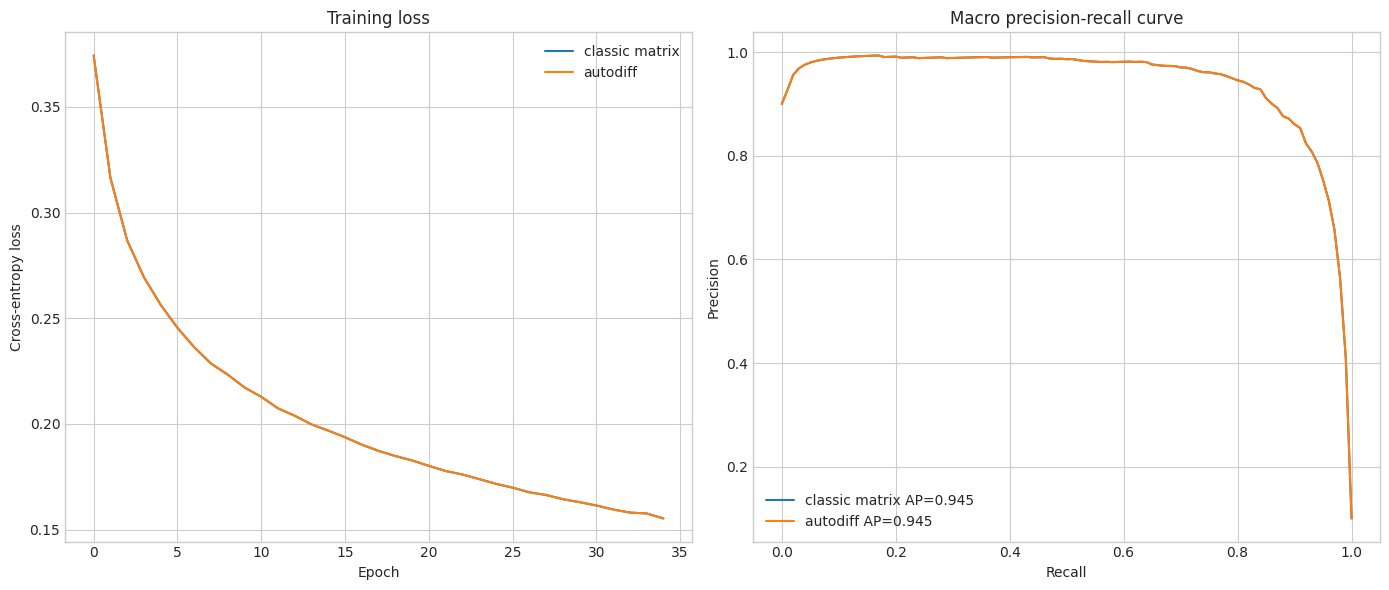

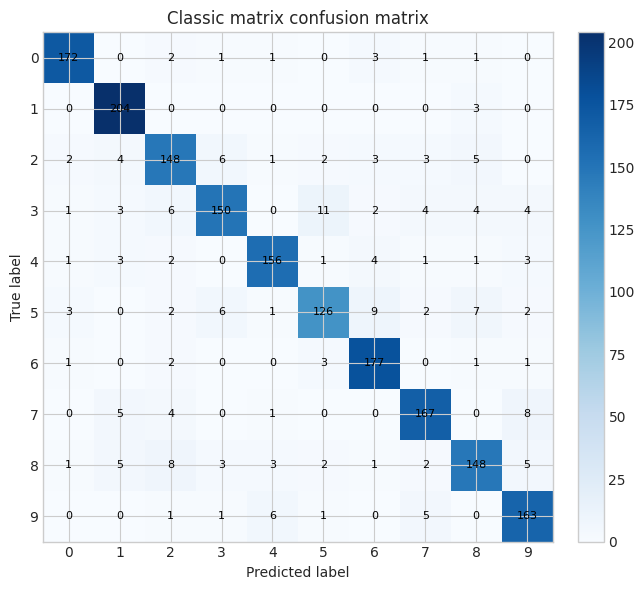

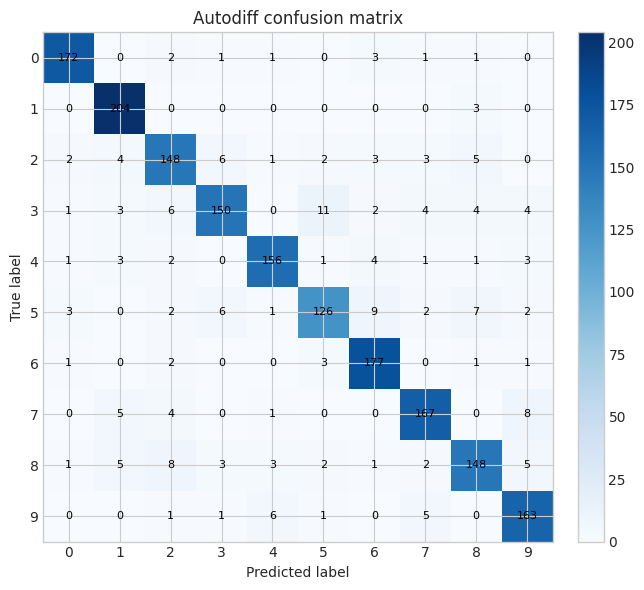

In [5]:
def evaluate_classifier(model, x: np.ndarray, y: np.ndarray):
    proba = model.predict_proba(x)
    pred = np.argmax(proba, axis=1)
    cm = confusion_matrix_numpy(y, pred)
    metrics, accuracy = metrics_from_cm(cm)
    return {
        "pred": pred,
        "proba": proba,
        "cm": cm,
        "metrics": metrics,
        "accuracy": accuracy,
    }


def convergence_rate(history: list[float]) -> float:
    values = np.asarray(history, dtype=np.float64)
    return (values[0] - values[-1]) / max(len(values) - 1, 1)


start_time = time.perf_counter()
matrix_model = SoftmaxLinearMatrix(n_features=X_train_scaled.shape[1], lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED)
matrix_model.fit(X_train_scaled, y_train)
matrix_time = time.perf_counter() - start_time
matrix_eval = evaluate_classifier(matrix_model, X_test_scaled, y_test)
matrix_test_pred = matrix_eval["pred"]
matrix_test_proba = matrix_eval["proba"]
matrix_cm = matrix_eval["cm"]
matrix_metrics = matrix_eval["metrics"]
matrix_accuracy = matrix_eval["accuracy"]
matrix_convergence = convergence_rate(matrix_model.loss_history_)

start_time = time.perf_counter()
autodiff_model = SoftmaxLinearAutodiff(n_features=X_train_scaled.shape[1], lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED)
autodiff_model.fit(X_train_scaled, y_train)
autodiff_time = time.perf_counter() - start_time
autodiff_eval = evaluate_classifier(autodiff_model, X_test_scaled, y_test)
autodiff_test_pred = autodiff_eval["pred"]
autodiff_test_proba = autodiff_eval["proba"]
autodiff_cm = autodiff_eval["cm"]
autodiff_metrics = autodiff_eval["metrics"]
autodiff_accuracy = autodiff_eval["accuracy"]
autodiff_convergence = convergence_rate(autodiff_model.loss_history_)

matrix_curve_x, matrix_curve_y, matrix_ap_scores, _ = macro_precision_recall_curve(y_test, matrix_test_proba)
autodiff_curve_x, autodiff_curve_y, autodiff_ap_scores, _ = macro_precision_recall_curve(y_test, autodiff_test_proba)

convergence_summary = pd.DataFrame(
    [
        {"model": "classic matrix", **convergence_summary_from_history(matrix_model.loss_history_), "accuracy": matrix_accuracy, "time_sec": matrix_time},
        {"model": "autodiff", **convergence_summary_from_history(autodiff_model.loss_history_), "accuracy": autodiff_accuracy, "time_sec": autodiff_time},
    ]
)
comparison = pd.DataFrame(
    [
        {
            "model": "classic matrix",
            "accuracy": matrix_accuracy,
            "macro_precision": float(matrix_metrics.loc["macro avg", "precision"]),
            "macro_recall": float(matrix_metrics.loc["macro avg", "recall"]),
            "macro_f1": float(matrix_metrics.loc["macro avg", "f1"]),
            "time_sec": matrix_time,
        },
        {
            "model": "autodiff",
            "accuracy": autodiff_accuracy,
            "macro_precision": float(autodiff_metrics.loc["macro avg", "precision"]),
            "macro_recall": float(autodiff_metrics.loc["macro avg", "recall"]),
            "macro_f1": float(autodiff_metrics.loc["macro avg", "f1"]),
            "time_sec": autodiff_time,
        },
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(matrix_model.loss_history_, label="classic matrix")
axes[0].plot(autodiff_model.loss_history_, label="autodiff")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].plot(matrix_curve_x, matrix_curve_y, label=f"classic matrix AP={np.mean(list(matrix_ap_scores.values())):.3f}")
axes[1].plot(autodiff_curve_x, autodiff_curve_y, label=f"autodiff AP={np.mean(list(autodiff_ap_scores.values())):.3f}")
axes[1].set_title("Macro precision-recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()

print("Comparison summary")
print(comparison)

plot_confusion_matrix(matrix_cm, "Classic matrix confusion matrix")
plot_confusion_matrix(autodiff_cm, "Autodiff confusion matrix")

print("Per-class metrics for the autodiff model")
print(autodiff_metrics)

## 2. Stratified K-fold validation for the MLP

In [6]:
def stratified_kfold_indices(y: np.ndarray, n_splits: int = K_FOLDS, seed: int = SEED):
    rng_local = np.random.default_rng(seed)
    classes = np.unique(y)
    fold_parts = [[] for _ in range(n_splits)]
    for cls in classes:
        cls_idx = np.flatnonzero(y == cls)
        rng_local.shuffle(cls_idx)
        cls_splits = np.array_split(cls_idx, n_splits)
        for fold_id, split in enumerate(cls_splits):
            fold_parts[fold_id].append(split)
    folds = []
    all_idx = np.arange(len(y))
    for fold_id in range(n_splits):
        val_idx = np.concatenate(fold_parts[fold_id])
        train_idx = np.setdiff1d(all_idx, val_idx, assume_unique=False)
        rng_local.shuffle(train_idx)
        rng_local.shuffle(val_idx)
        folds.append((train_idx, val_idx))
    return folds


def run_mlp_cv(x: np.ndarray, y: np.ndarray, n_splits: int = K_FOLDS, epochs: int = 20):
    folds = stratified_kfold_indices(y, n_splits=n_splits, seed=SEED)
    rows = []
    for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
        model = SoftmaxLinearAutodiff(
            n_features=x.shape[1],
            lr=LR,
            epochs=epochs,
            batch_size=BATCH_SIZE,
            seed=SEED + fold_id,
        )
        model.fit(x[train_idx], y[train_idx])
        fold_eval = evaluate_classifier(model, x[val_idx], y[val_idx])
        fold_metrics = fold_eval["metrics"].loc["macro avg"]
        rows.append(
            {
                "fold": fold_id,
                "accuracy": fold_eval["accuracy"],
                "precision": float(fold_metrics["precision"]),
                "recall": float(fold_metrics["recall"]),
                "f1": float(fold_metrics["f1"]),
                "final_loss": model.loss_history_[-1],
            }
        )
    return pd.DataFrame(rows)


cv_results_mlp = run_mlp_cv(X_cv_scaled, y_cv, n_splits=K_FOLDS, epochs=20)
mlp_cv_bar = cv_results_mlp[["accuracy", "precision", "recall", "f1"]].mean()
print(cv_results_mlp)
print("Mean CV metrics")
print(mlp_cv_bar)

final_mlp = SoftmaxLinearAutodiff(n_features=X_dev_scaled.shape[1], lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED)
final_mlp.fit(X_dev_scaled, y_dev)
final_mlp_eval = evaluate_classifier(final_mlp, X_test_scaled, y_test)
final_mlp_pred = final_mlp_eval["pred"]
final_mlp_metrics = final_mlp_eval["metrics"]
print("Final MLP test metrics")
print(final_mlp_metrics)

   fold  accuracy  precision    recall        f1  final_loss
0     1  0.895742   0.894401  0.893912  0.893928    0.170576
1     2  0.903526   0.902830  0.901923  0.901831    0.185361
2     3  0.901913   0.900849  0.900279  0.900092    0.186890
3     4  0.897448   0.896589  0.895791  0.895435    0.180854
4     5  0.918468   0.917559  0.916551  0.916720    0.186648
Mean CV metrics
accuracy     0.903419
precision    0.902446
recall       0.901691
f1           0.901601
dtype: float64
Final MLP test metrics
           precision    recall        f1  support
0           0.955556  0.950276  0.952909    181.0
1           0.918919  0.985507  0.951049    207.0
2           0.872093  0.862069  0.867052    174.0
3           0.890173  0.832432  0.860335    185.0
4           0.907514  0.912791  0.910145    172.0
5           0.888112  0.803797  0.843854    158.0
6           0.912821  0.962162  0.936842    185.0
7           0.898396  0.908108  0.903226    185.0
8           0.879310  0.859551  0.869318  

## 3. PCA + impurity-based classification tree


In [ ]:
def fit_pca_jax(x: np.ndarray, n_components: int = PCA_COMPONENTS):
    x_j = jnp.asarray(x, dtype=jnp.float32)
    mean = jnp.mean(x_j, axis=0, keepdims=True)
    centered = x_j - mean
    covariance = (centered.T @ centered) / (centered.shape[0] - 1)
    eigenvalues, eigenvectors = jnp.linalg.eigh(covariance)
    order = jnp.argsort(eigenvalues)[::-1]
    components = eigenvectors[:, order[:n_components]]
    explained = eigenvalues[order[:n_components]] / jnp.sum(eigenvalues)
    return mean, components, explained


def apply_pca(x: np.ndarray, mean, components):
    x_j = jnp.asarray(x, dtype=jnp.float32)
    return (x_j - mean) @ components


@dataclass
class TreeNode:
    prediction: int
    feature: int = -1
    threshold: float = 0.0
    left: object = None
    right: object = None


class DecisionTreeImpurity:
    def __init__(self, n_classes: int = NUM_CLASSES, max_depth: int = TREE_MAX_DEPTH, min_samples_split: int = TREE_MIN_SAMPLES_SPLIT, min_samples_leaf: int = TREE_MIN_SAMPLES_LEAF, max_features: int = TREE_MAX_FEATURES, threshold_count: int = TREE_THRESHOLD_COUNT, seed: int = SEED):
        self.n_classes = n_classes
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.threshold_count = threshold_count
        self.seed = seed
        self.rng = np.random.default_rng(seed)

    def _gini(self, y: np.ndarray) -> float:
        counts = np.bincount(y, minlength=self.n_classes).astype(np.float64)
        probabilities = counts / np.maximum(counts.sum(), 1)
        return 1.0 - np.sum(probabilities ** 2)

    def _best_split(self, x: np.ndarray, y: np.ndarray):
        n_samples, n_features = x.shape
        feature_indices = np.arange(n_features)
        if self.max_features is not None and self.max_features < n_features:
            feature_indices = self.rng.choice(n_features, size=self.max_features, replace=False)
        best_feature = None
        best_threshold = None
        best_impurity = np.inf
        candidate_grid = np.linspace(0.1, 0.9, self.threshold_count)
        for feature in feature_indices:
            values = x[:, feature]
            if np.allclose(values, values[0]):
                continue
            thresholds = np.unique(np.quantile(values, candidate_grid))
            for threshold in thresholds:
                left_mask = values <= threshold
                left_count = int(left_mask.sum())
                right_count = n_samples - left_count
                if left_count < self.min_samples_leaf or right_count < self.min_samples_leaf:
                    continue
                y_left = y[left_mask]
                y_right = y[~left_mask]
                impurity = (left_count / n_samples) * self._gini(y_left) + (right_count / n_samples) * self._gini(y_right)
                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = int(feature)
                    best_threshold = float(threshold)
        return best_feature, best_threshold, best_impurity

    def _build(self, x: np.ndarray, y: np.ndarray, depth: int):
        prediction = int(np.bincount(y, minlength=self.n_classes).argmax())
        if (
            depth >= self.max_depth
            or len(np.unique(y)) == 1
            or len(y) < self.min_samples_split
        ):
            return TreeNode(prediction=prediction)
        feature, threshold, impurity = self._best_split(x, y)
        if feature is None:
            return TreeNode(prediction=prediction)
        left_mask = x[:, feature] <= threshold
        right_mask = ~left_mask
        if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
            return TreeNode(prediction=prediction)
        left_node = self._build(x[left_mask], y[left_mask], depth + 1)
        right_node = self._build(x[right_mask], y[right_mask], depth + 1)
        return TreeNode(prediction=prediction, feature=feature, threshold=threshold, left=left_node, right=right_node)

    def fit(self, x: np.ndarray, y: np.ndarray):
        x = np.asarray(x, dtype=np.float32)
        y = np.asarray(y, dtype=np.int32)
        self.root_ = self._build(x, y, 0)
        return self

    def _predict_one(self, row: np.ndarray) -> int:
        node = self.root_
        while node.left is not None and node.right is not None:
            node = node.left if row[node.feature] <= node.threshold else node.right
        return node.prediction

    def predict(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=np.float32)
        return np.array([self._predict_one(row) for row in x], dtype=np.int32)

    def predict_proba(self, x: np.ndarray) -> np.ndarray:
        pred = self.predict(x)
        return np.eye(self.n_classes, dtype=np.float32)[pred]


def run_tree_cv(x: np.ndarray, y: np.ndarray, n_splits: int = K_FOLDS):
    folds = stratified_kfold_indices(y, n_splits=n_splits, seed=SEED)
    rows = []
    for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
        x_train_fold = x[train_idx]
        y_train_fold = y[train_idx]
        x_val_fold = x[val_idx]
        y_val_fold = y[val_idx]
        pca_mean, pca_components, pca_explained = fit_pca_jax(x_train_fold, PCA_COMPONENTS)
        x_train_pca = np.asarray(apply_pca(x_train_fold, pca_mean, pca_components))
        x_val_pca = np.asarray(apply_pca(x_val_fold, pca_mean, pca_components))
        tree = DecisionTreeImpurity(seed=SEED + fold_id)
        tree.fit(x_train_pca, y_train_fold)
        fold_eval = evaluate_classifier(tree, x_val_pca, y_val_fold)
        fold_metrics = fold_eval["metrics"].loc["macro avg"]
        rows.append(
            {
                "fold": fold_id,
                "accuracy": fold_eval["accuracy"],
                "precision": float(fold_metrics["precision"]),
                "recall": float(fold_metrics["recall"]),
                "f1": float(fold_metrics["f1"]),
                "explained_variance": float(np.asarray(pca_explained).sum()),
            }
        )
    return pd.DataFrame(rows)


cv_results_tree = run_tree_cv(X_cv_scaled, y_cv, n_splits=K_FOLDS)
tree_rows = cv_results_tree.to_dict(orient="records")
print(cv_results_tree)
print("Mean tree CV metrics")
print(cv_results_tree[["accuracy", "precision", "recall", "f1"]].mean())

final_tree_mean, final_tree_components, final_tree_explained = fit_pca_jax(X_dev_scaled, PCA_COMPONENTS)
X_dev_tree_pca = np.asarray(apply_pca(X_dev_scaled, final_tree_mean, final_tree_components))
X_test_tree_pca = np.asarray(apply_pca(X_test_scaled, final_tree_mean, final_tree_components))
final_tree = DecisionTreeImpurity(seed=SEED)
final_tree.fit(X_dev_tree_pca, y_dev)
final_tree_eval = evaluate_classifier(final_tree, X_test_tree_pca, y_test)
final_tree_pred = final_tree_eval["pred"]
final_tree_metrics = final_tree_eval["metrics"]
final_tree_components = final_tree_components
final_tree_mean = final_tree_mean
print("Final tree test metrics")
print(final_tree_metrics)

comparison = pd.DataFrame(
    [
        {
            "model": "MLP autodiff",
            "accuracy": final_mlp_eval["accuracy"],
            "precision": float(final_mlp_metrics.loc["macro avg", "precision"]),
            "recall": float(final_mlp_metrics.loc["macro avg", "recall"]),
            "f1": float(final_mlp_metrics.loc["macro avg", "f1"]),
        },
        {
            "model": "Tree + PCA",
            "accuracy": final_tree_eval["accuracy"],
            "precision": float(final_tree_metrics.loc["macro avg", "precision"]),
            "recall": float(final_tree_metrics.loc["macro avg", "recall"]),
            "f1": float(final_tree_metrics.loc["macro avg", "f1"]),
        },
    ]
)
print("MLP vs tree comparison")
print(comparison)

   fold  accuracy  precision    recall        f1  explained_variance
0     1  0.617230   0.628230  0.610951  0.614438            1.000000
1     2  0.629285   0.631533  0.621881  0.619171            1.000001
2     3  0.683668   0.688595  0.677211  0.677443            1.000000
3     4  0.703140   0.707185  0.699549  0.699171            1.000001
4     5  0.657171   0.666416  0.650307  0.651910            1.000001
Mean tree CV metrics
accuracy     0.658099
precision    0.664392
recall       0.651980
f1           0.652426
dtype: float64
Final tree test metrics
           precision    recall        f1  support
0           0.764331  0.662983  0.710059    181.0
1           0.928205  0.874396  0.900498    207.0
2           0.646341  0.609195  0.627219    174.0
3           0.553459  0.475676  0.511628    185.0
4           0.557692  0.674419  0.610526    172.0
5           0.536585  0.556962  0.546584    158.0
6           0.727778  0.708108  0.717808    185.0
7           0.792208  0.659459  0.7197

## Comparison and interpretation

- The classic matrix MLP and the autodiff MLP optimize the same softmax cross-entropy objective, so their test behavior should be very close.
- The autodiff version is shorter and easier to modify; the classic matrix version makes the gradient algebra explicit.
- The tree is more interpretable, but the PCA step and the impurity-based splits usually trade some accuracy for that interpretability.
- If you rerun the notebook, the printed tables summarize accuracy, precision, recall, F1, convergence, and the MLP-vs-tree comparison.